## Athena Mustakis
## Problem 1. Principle Component Analysis
A) Visualize the raw data for all of the points in the 3rd versus the 18th dimensions in the datapoints.csv file.

In [1]:
# do basic imports
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps
import pandas as pd 
import pickle

In [2]:
data = pd.read_csv('datapoints.csv') #import data 
df = pd.DataFrame(data) #
#print(df.head())
print(df.shape)
print(df['0'].shape)

(300, 20)
(300,)


Text(0.5, 1.0, 'Visualization of 3rd vs 18th dimensions')

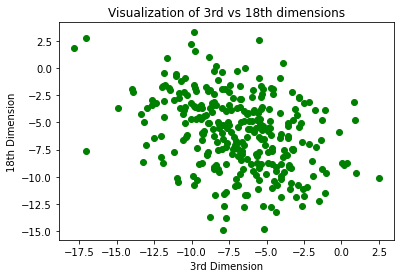

In [3]:
plt.plot(df['3'],df['18'],'o', color = 'green')
plt.xlabel('3rd Dimension')
plt.ylabel('18th Dimension')
plt.title('Visualization of 3rd vs 18th dimensions')

B) Perform a principle component analysis (PCA) on the data and return all the principle components. Show the principle components in a pandas data-frame.

In [4]:
from sklearn.decomposition import PCA

In [5]:
#finding the principle components
pca = PCA(n_components = 20) #this defines the model, there are 20 columns so that means 20 variables so 20 PC components 
p = pca.fit_transform(df) 
pcadf = pd.DataFrame(data = p, columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6','PC7','PC8','PC9', 'PC10','PC11','PC12','PC13','PC14','PC15','PC16','PC17','PC18','PC19','PC20'])
print(pcadf)

           PC1        PC2       PC3       PC4       PC5       PC6       PC7  \
0    19.449531  -9.205561  1.483845  0.298622  1.907189  1.932403  1.805941   
1    14.256032  -4.787531  0.635671  4.235459 -0.663979  8.090297 -2.070789   
2     2.614282  16.753922 -0.460214  3.850638 -1.667367 -2.516891 -5.088551   
3   -13.155587  -4.439978  2.577246 -4.931699 -0.688698  3.164437  1.635518   
4   -15.915419  -5.929977  2.415124  1.652355  0.199788 -2.590344 -1.357000   
..         ...        ...       ...       ...       ...       ...       ...   
295   0.019962  16.350879  5.228203  0.194244  5.513870  3.494995  2.170749   
296  -3.050148  21.867717 -1.812844 -1.445882  0.748240  0.859756 -0.486510   
297 -15.168477  -6.608786  3.552535  2.486504  1.815216 -4.469368 -1.949865   
298   1.322555  22.126099 -5.463404  0.061418 -2.887073  1.963890  1.702409   
299   1.473089  12.065865 -1.427828 -7.251994 -2.492307  0.538678  4.654171   

          PC8       PC9      PC10      PC11      PC

C) Plot the variance captured by each principal component. Based on this plot, ex- plain if PCA is a good option to reduce the dimensions of the given data.

[0.43564073 0.28191603 0.02329473 0.02145605 0.02091404 0.0206554
 0.01796797 0.01758981 0.01711461 0.01572273 0.0154126  0.01461655
 0.01417692 0.01360172 0.01300943 0.01224864 0.0121201  0.01145212
 0.01099109 0.01009872]
Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10',
       'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19',
       'PC20'],
      dtype='object')


Text(0.5, 1.0, 'Variance Captured by Each Principal Component')

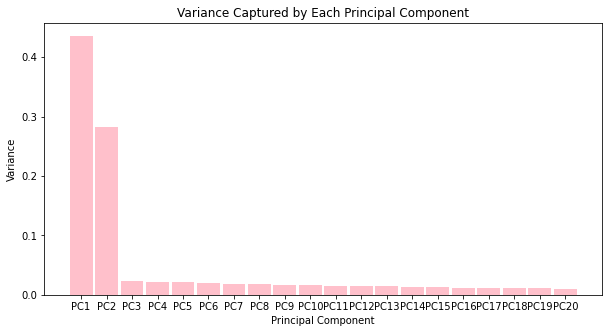

In [6]:
#make a plot where y-axis is variance and x-axis is the principle component 
v = pca.explained_variance_ratio_ #variance captured for each principal component 
print(v)
#varper = np.cumsum(np.round(v,decimals=3)*100) #percent variance explained for each principal component 
#print(varper)
pc = pcadf.keys() #get the PC names for the x-axis 
print(pc)
fig = plt.figure(figsize = (10,5)) #increase the figure size 
plt.bar(pc,v, color = 'pink', width = 0.9)
plt.xlabel('Principal Component')
plt.ylabel('Variance')
plt.title('Variance Captured by Each Principal Component')

Explain if PCA is a good option to reduce the dimensions of the given data based on the plot


I believe yes because most of the variance is explained by the first two PC in the plot and the rest of the principal components do not explain that much variance. 

D) Plot the first two principal components. Make sure to include the variance cap- tured by the first two principal components in the axis labels.


300
300


Text(0.5, 1.0, 'PCA Visualization')

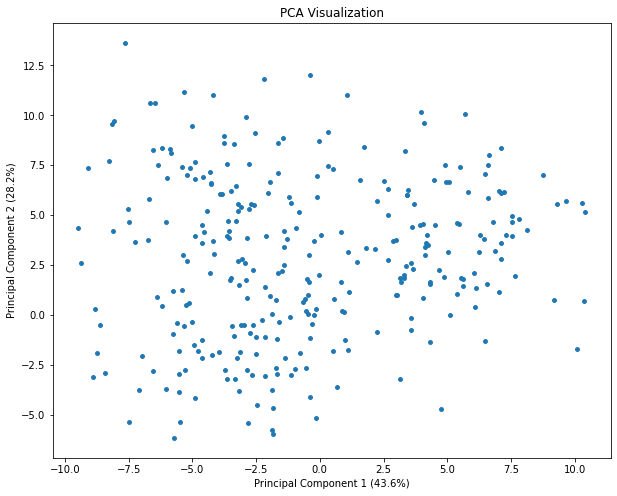

In [7]:
X_pca = pca.transform(p) #transform the data into PCA space 
print(len(p[:,0])) #that is principal component 1 
print(len(p[:,1])) #that is principal component 2
#x = p.transform(df)
#target = np.zeros(df.shape[0])
plt.figure(figsize=(10,8))
plt.scatter(X_pca[:,0],X_pca[:,1], s=15)
plt.xlabel('Principal Component 1 (43.6%)')
plt.ylabel('Principal Component 2 (28.2%)')
plt.title('PCA Visualization')
#need to add variance captured by the first two principal components in the axis labels 

## Problem 2. K-Means Clustering

A) Using the principle component data generated from problem 1A, plot the sum of squared distances of all points in a cluster for all principal components (1-20). Please use sklearn’s KMeans method and its attribute kmeans.inertia to obtain the sum of squared distances. From this plot, you should be able to deduce the optimal number of clusters. Please report the optimal number of clusters based on your plot.

In [8]:
#plot the sum of squared distances of all points in a cluster for all principal components 
#used sklearns Kmeans methods and kmean.intertia to obtain the sum of squareed distances 

Text(0.5, 1.0, 'Elbow Plot')

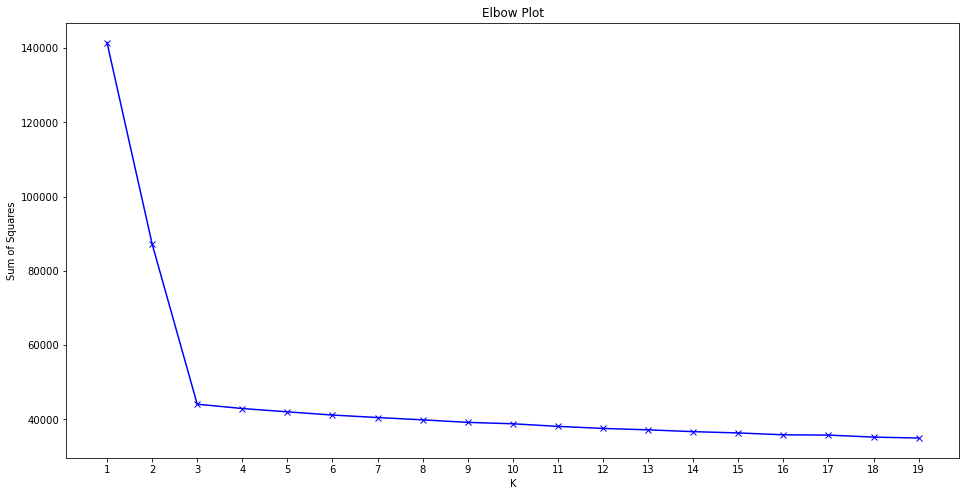

In [9]:
from sklearn.cluster import KMeans
inertia = [] #empty list in order to place the values from the inertia 
 #there are 20 prinicipal components so make it go through a range of 20
point = range(1,20)
for i in range(1,20):
    kmean = KMeans(n_clusters = i)
    kmean.fit(pcadf)
    inertia.append(kmean.inertia_)
    
plt.figure(figsize=(16,8))
plt.plot(point,inertia, 'bx-')
plt.xticks(point) #set up the tick marks correctly 
plt.xlabel('K')
plt.ylabel('Sum of Squares')
plt.title('Elbow Plot')

In [10]:
#select value of K at the elbow of the graph which is the point after the interia started decreasing 
#based on the plot I would say the optimal number is k=3 

B) Perform K-Means clustering using the first two dimensions of the ORIGINAL DATA (data from the datapoints.csv). To determine the number of clusters that you should begin with, refer to your elbow plot from problem 2A, and randomly generate the points of centroids according to that cluster number (i.e. if you reported the optimal number of clusters to be 10 in problem 2A, you should start with 10 centroids). Before generating these centroids, set your random seed as follows: random.seed(10). Perform 10 iterations of K-Means. Finally, plot the K-Means clusters. It should be clear on the plot as to what cluster each point belongs to (i.e. each cluster should be a different color). This plot should also contain the final calculated centroid for each cluster. Make sure to include a legend for your plot.


In [11]:
#make multiple functions 
#one to calculate the distance betweeen poitns and the centroids 
#one to calculate a list of points close to each centroids 
#one to calculate the new centroid from the list of points in that cluster 

zero = df['0'].values #subset the orginal dataframe so that we are only looking at the first two dimensions of th eorginal data 
one = df['1'].values
partb = np.array(list(zip(zero,one))) #combine the two values together 

#iterations = 10 #amount of times we are going to run the simulations 
#K = 3 #number of clusters 

Text(0.5, 1.0, 'Visualization of First Two Dimensions')

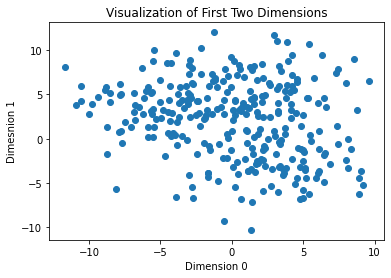

In [12]:
plt.scatter(zero,one)
plt.xlabel('Dimension 0')
plt.ylabel('Dimesnion 1')
plt.title('Visualization of First Two Dimensions')

In [18]:
#first function 
import random
#calculating the distance between points and the centroids 
def randomcentroids(Y,k): 
    '''Obtaining the random centroids from the data '''
    #for i in range(k):
    random.seed(3)
    #using random random int to a value that is betweeen 0 and the max value of the dataset 
    coord1 = np.random.randint(0,np.max(Y),size= k) #getting the random value for x axis and getting three if them because three centroids 
    coord2 = np.random.randint(0,np.max(Y),size =k) #getting the random values for the y-axis 
    centcord = np.array(list(zip(coord1, coord2))) #putting them together in order to get x and y coordinates 
    return centcord
c = randomcentroids(partb, 3)
print(c)
#print(c[0])
#print(c[0,0],c[0,1])
#print(c[1,0],c[1,1])
#print(c[2,0],c[2,1])

[[ 0  1]
 [ 8  8]
 [ 1 10]]


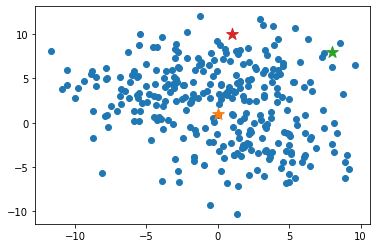

In [19]:
plt.scatter(zero,one)
#plotting the random centoids that were made to see how it is in the data 
#using a star to mark the centroids 
plt.scatter(c[0,0],c[0,1], marker = "*", s =150) #adding the centroid points into the plot to visulize them 
plt.scatter(c[1,0],c[1,1] ,marker = "*", s = 150)
plt.scatter(c[2,0],c[2,1] , marker = "*", s= 150)

In [22]:
def distance(Y,k,c):#function to make the distances and it will take in the data, number of clusters, and centroids made before 
    '''taking the random clusters formed previously and assinging each point to a cluster then calculating means again to get the clusters, process is repeated 10 times'''
    center = []
    for i in range(10): #we are running the iteration ten times 
        dim= Y.shape[0] #get the shape of the data 
        idx = np.zeros(dim) 
        for i in range(dim):
            clus = np.zeros(k) #make a numpy array 
            for j in range(k): 
                clus[j] = np.sum((Y[i,:]-c[j,:])**2) #calculating the distance between the points and the centroid 
                idx[i]= np.argmin(clus) #take the arg min
        for l in range(k):
            points = [Y[j] for j in range(len(Y)) if idx[j] == l]
            c[l] = np.mean(points, axis=0) #calculating the means based on the points in order to get the new centroids 
            print(c[l]) #printing all the new clusters just to see 
    return idx
d= distance(partb,3,c)
#print(d)
#print(center)

[ 2 -2]
[2 5]
[-5  3]
[ 2 -2]
[2 5]
[-5  3]
[ 2 -2]
[2 5]
[-5  3]
[ 2 -2]
[2 5]
[-5  3]
[ 2 -2]
[2 5]
[-5  3]
[ 2 -2]
[2 5]
[-5  3]
[ 2 -2]
[2 5]
[-5  3]
[ 2 -2]
[2 5]
[-5  3]
[ 2 -2]
[2 5]
[-5  3]
[ 2 -2]
[2 5]
[-5  3]


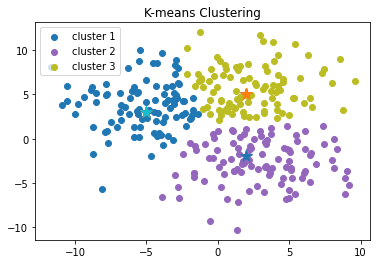

In [17]:
cluster = ['cluster 1', 'cluster 2', 'cluster 3']
for i in range(3): 
    points = np.array([partb[j] for j in range(len(partb)) if d[j]==i])
    plt.scatter(points[:,0], points[:,1], label = cluster[i])
    plt.legend()
    plt.scatter(-5,3,marker = "*", s=150)
    plt.scatter(2,-2,marker = "*", s = 150)
    plt.scatter(2,5, marker = "*", s = 150)
    plt.title("K-means Clustering")